In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Features: [size_sqft, bedrooms, age_years]
X = np.array([
    [900,  2, 10],
    [1100, 3,  7],
    [1400, 3,  5],
    [1600, 4,  4],
    [1900, 4,  2],
    [2300, 5,  1]
], dtype=float)

# Target: price_lakhs
y = np.array([66, 79, 96, 111, 132, 158], dtype=float)

m ,n = X.shape

print("X shape: ", X.shape)
print("y shape: ", y.shape)
print("m =", m, ", n =", n)


X shape:  (6, 3)
y shape:  (6,)
m = 6 , n = 3


In [6]:
def standardize_features(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma==0] = 1.0
    X_scaled = (X - mu) / sigma
    return X_scaled, mu, sigma

def apply_standardization(X, mu, sigma):
    return (X - mu) / sigma

X_scaled, mu, sigma = standardize_features(X)

print("\nFeature means: ",mu)
print("Feature std:",sigma)
print("Scaled X: \n",X_scaled)


Feature means:  [1533.33333333    3.5           4.83333333]
Feature std: [471.40452079   0.95742711   3.02305952]
Scaled X: 
 [[-1.34350288 -1.5666989   1.70908532]
 [-0.91923882 -0.52223297  0.7167132 ]
 [-0.28284271 -0.52223297  0.05513178]
 [ 0.14142136  0.52223297 -0.27565892]
 [ 0.77781746  0.52223297 -0.93724034]
 [ 1.6263456   1.5666989  -1.26803105]]


In [5]:
def predict(x, w, b):
    return np.dot(x,w) + b

In [7]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    cost = 0.0

    for i in range(m):
        f_wb = predict(X[i], w, b)
        error = f_wb - y[i]
        cost += error ** 2

    return cost / (2 * m)


In [8]:
def compute_gradient(X, y, w, b):

    m, n = X.shape

    dj_dw = np.zeros(n)
    dj_db = 0.0

    for i in range(m):
        f_wb = predict(X[i], w, b)
        error = f_wb - y[i]

        for j in range(n):
            dj_dw[j] += error * X[i, j]

        dj_db += error
    
    dj_dw = dj_dw / m
    dj_db = dj_db / m

    return dj_dw, dj_db


In [9]:
def gradient_descent(X, y, w, b, alpha, iterations):
    cost_history =[]

    for i in range(iterations):
        dj_dw, dj_db = compute_gradient(X, y, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost(X, y, w, b)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"iteration {i}: Cost = {cost:.4f}")

    return w, b, cost_history

In [ ]:
w = np.zeros(n)
b = 0.0

alpha = 0.1
iterations = 10000

In [40]:
w, b, cost_history = gradient_descent(X_scaled, y, w, b, alpha, iterations)

print("w =", w)
print("b =",b)

iteration 0: Cost = 4886.2418
iteration 100: Cost = 6.4217
iteration 200: Cost = 3.6072
iteration 300: Cost = 2.1130
iteration 400: Cost = 1.3180
iteration 500: Cost = 0.8944
iteration 600: Cost = 0.6685
iteration 700: Cost = 0.5480
iteration 800: Cost = 0.4836
iteration 900: Cost = 0.4492
iteration 1000: Cost = 0.4309
iteration 1100: Cost = 0.4211
iteration 1200: Cost = 0.4158
iteration 1300: Cost = 0.4130
iteration 1400: Cost = 0.4115
iteration 1500: Cost = 0.4107
iteration 1600: Cost = 0.4103
iteration 1700: Cost = 0.4101
iteration 1800: Cost = 0.4099
iteration 1900: Cost = 0.4099
iteration 2000: Cost = 0.4098
iteration 2100: Cost = 0.4098
iteration 2200: Cost = 0.4098
iteration 2300: Cost = 0.4098
iteration 2400: Cost = 0.4098
iteration 2500: Cost = 0.4098
iteration 2600: Cost = 0.4098
iteration 2700: Cost = 0.4098
iteration 2800: Cost = 0.4098
iteration 2900: Cost = 0.4098
iteration 3000: Cost = 0.4098
iteration 3100: Cost = 0.4098
iteration 3200: Cost = 0.4098
iteration 3300: Cos

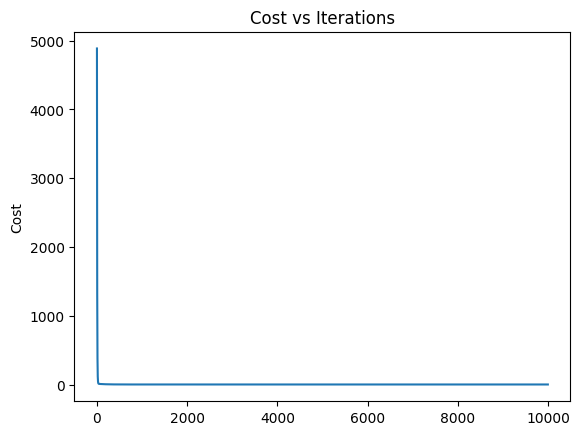

In [41]:
plt.plot (cost_history)
plt.title("Cost vs Iterations")
plt.ylabel("Cost")
plt.show()

In [47]:
new_house = np.array([[1000, 3, 5]], dtype=float)
new_house_scaled = apply_standardization(new_house, mu, sigma)

predicted_price = predict(new_house_scaled[0], w, b)

print(f"\nPredicted price for {new_house[0]} is {predicted_price:.2f} lakhs")


Predicted price for [1000.    3.    5.] is 70.05 lakhs
